# AFM Simulation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.optimize import curve_fit
from typing import Tuple, Optional

We implement different processors as different classes. We will seperate the cantilever, the contact mechanics and the spatial structure.

## Cantilever 
This class will give us the power spectral density (PSD) for a choosen cantilever. The user must input the spring constant $k$, the resonant frequency $f_0$ and the quality factor $Q$. These information is provided by the producer. Also, the temperature $T$ that will be used during the experiments must be indicated.
These information will be used to calculate the thermal noise and to calculate the forces in our system. 

In [3]:
class AFMCantilever:
    def __init__(self, 
                 k: float = 0.5,  # Spring constant [N/m]
                 f0: float = 75e3,  # Resonance frequency [Hz]
                 Q: float = 100,  # Quality factor
                 T: float = 300):  # Temperature [K]

        self.k = k
        self.f0 = f0
        self.Q = Q
        self.T = T
        self.kB = 1.380649e-23  # Boltzmann constant [J/K]
        
        self.m_eff = k / (2 * np.pi * f0)**2
        
        self.gamma = 2 * np.pi * f0 * self.m_eff / Q
        
    def thermal_noise_rms(self) -> float:
        return np.sqrt(self.kB * self.T / self.k)
    
    def thermal_noise_psd_theoretical(self, f: np.ndarray) -> np.ndarray:
        omega = 2 * np.pi * f
        omega0 = 2 * np.pi * self.f0
        
        denominator = (omega0**2 - omega**2)**2 + (omega * omega0 / self.Q)**2
        S_x = (4 * self.kB * self.T * self.gamma) / (self.k**2 * denominator)
        
        return S_x

    def thermal_noise_psd_experimental(self, path: str) -> np.ndarray:
        data = np.loadtxt(path, skiprows=24)
        f = data[:, 0]
        Sv = data[:, 1]
        value = 12.6487
        S_x = S_v * (value*1e-9)**2
        return f, S_x

    def generate_thermal_noise(self, n_points: int, fs: float, type: str) -> np.ndarray:

        dt = 1/fs

        if type == "Theoretical":
            freqs = np.fft.rfftfreq(n_points, dt)
            psd = self.thermal_noise_psd_theoretical(freqs)
        elif type == "Experimental":
            freqs, psd = self.thermal_noise_psd_experimental(path)
        
        amplitudes = np.sqrt(psd * fs / 2)
        phase = np.random.uniform(0, 2*np.pi, len(freqs))
        fourier_coeffs = amplitudes * np.exp(1j * phase)
        
        fourier_coeffs[0] = np.abs(fourier_coeffs[0])
        
        noise = np.fft.irfft(fourier_coeffs, n_points)
        
        return noise

## Contact Mechanics
The contact mechanics that will be used to analyze the interaction between the cantilever and the sample must be selected by the user. Here we provide an exemple using the Hertz contact mechanics. 

In [4]:
class HertzContact:
    def __init__(self, 
                 R: float = 10e-9,   # Tip radius [m]
                 nu: float = 0.5,    # Poisson ratio of sample
                 alpha: float = 18): # Face angle of the pyramid
        self.R = R
        self.nu = nu
        self.alpha = alpha

    def hertz_sphere(self, ind, E:float):
        return (4/3) * E * np.sqrt(self.R) * ind**(3/2) / (1 - self.nu**2)

    def hertz_cone(self, ind, E:float):
        return E * np.tan(self.alpha) * ind**2 / (np.sqrt(2) *(1 - self.nu**2))
        
    def force(self, cantilever_shape: str, indentation: np.ndarray, contact_point:float, E:float) -> np.ndarray:
        indentation += contact_point + 1e-6
        ind = np.maximum(indentation, 0)

        if cantilever_shape == "Sphere":
            return self.hertz_sphere(ind, E)

        if cantilever_shape == "Pyramid":
            return self.hertz_cone(ind, E)


## Sample properties
Type of sample must be defined by the user. The expected forms and height ranges as well as expected stiffness values must be provided. Here we offer two exemples. One, a circular shape that can be used to illustrate cells. Second, gaussian features that can be use to illustrate tissue samples.

In [5]:
class Sample:

    def __init__(self, 
                 E_substrate_range= [10e3, 20e3], 
                 E_sample_range= [1e3, 2e3],
                 Height_range = [0, 5e-6]):
        self.E_substrate_range = E_substrate_range
        self.E_sample_range = E_sample_range
        self.Height_range = Height_range
        
    def create_topography(self, 
                         size: Tuple[int, int] = (128, 128),
                         pixel_size: float = 1e-6,
                         topography_type: str = 'gaussian_features') -> np.ndarray:
        ny, nx = size
        topo = np.zeros((ny, nx))
        E_map = np.zeros((ny, nx))
    
        if topography_type == 'gaussian_features':
            n_features = 10
            
            for _ in range(n_features):
                cx = np.random.randint(0, nx)
                cy = np.random.randint(0, ny)
                
                amplitude = np.random.uniform(min(self.Height_range), max(self.Height_range))
                sigma = np.random.uniform(5, 15)
                
                y, x = np.ogrid[0:ny, 0:nx]
                gaussian = amplitude * np.exp(-((x-cx)**2 + (y-cy)**2) / (2*sigma**2))
                topo += gaussian

            E_map = np.random.uniform(
                low=self.E_substrate_range[0],
                high=self.E_substrate_range[1],
                size=topo.shape
            )
    
            mask = topo > (np.mean(self.Height_range))
            adjustment = topo[mask]/max(topo[mask]) + 0.5
            E_map[mask] = np.random.uniform(
                low=self.E_sample_range[0],
                high=self.E_sample_range[1],
                size=np.sum(mask)
            )
            E_map[mask] = E_map[mask] / adjustment
            
            return topo, E_map
                
        elif topography_type == 'hemisphere':
            radius = ny//4
            cx, cy = nx//2, ny//2
            y,x, =np.ogrid[:ny, :nx]
            r = (x - cy)**2 + (y  - cx)**2
            mask = r <= radius**2
        
            topo[mask] =  self.Height_range[1] * np.sqrt(radius**2 - r[mask])
            
            E_map = np.random.uniform(
                low=self.E_substrate_range[0],
                high=self.E_substrate_range[1],
                size=topo.shape
            )
    
            mask = topo > 0
            adjustment = topo[mask]/max(topo[mask])
            E_map[mask] = np.random.uniform(
                low=self.E_sample_range[0],
                high=self.E_sample_range[1],
                size=np.sum(mask)
            )
            E_map[mask] = E_map[mask] / adjustment
            return topo, E_map

## The Simulator

In [6]:
class AFMSimulator:

    def __init__(self, cantilever: AFMCantilever, contact_model: HertzContact, sample: Sample):
        self.cantilever = cantilever
        self.contact_model = contact_model
        self.sample = sample
        
    def simulate_fdc(self, 
                    z_length: float = 10**6,
                    setpoint_force: float = 1e-9,
                    f: int = 2048, 
                    height: float = 2e-6,
                    E: float = 1e3, 
                    approach_rate: float = 2, # um/s
                    include_thermal_noise: bool = True) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:

        total_distance = z_length
        total_time = total_distance / (approach_rate * 1e-6)
        n_points = int(total_time * f)
        dt = 1/f
        
        z_piezo = np.concatenate([
            np.linspace(0, z_length, n_points),  # approach
            np.linspace(z_length,0, n_points)   # retract
        ])

        indentation = -z_piezo  
        
        force = self.contact_model.force("Sphere", indentation, height, E)

        deflection = force / self.cantilever.k

        if include_thermal_noise:
            thermal_noise = self.cantilever.generate_thermal_noise(len(z_piezo), dt)
            # sigma = self.cantilever.thermal_noise_rms()
            # thermal_noise = np.random.normal(0, sigma, size=len(deflection))
            deflection += thermal_noise
            force = deflection * self.cantilever.k
        
            return z_piezo, deflection, force, thermal_noise
            
        return z_piezo, deflection, force

    

## Necessary function for visualisation

In [68]:
def plot_maps(topography, E_map):
    fig = plt.figure(figsize=(12, 5))

    ax1 = fig.add_subplot(1, 2, 1)
    im1 = ax1.imshow(topography, cmap='viridis', aspect='equal')
    ax1.set_title('True Topography', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X [pixels]')
    ax1.set_ylabel('Y [pixels]')
    plt.colorbar(im1, ax=ax1, label='Height [m]')

    ax2 = fig.add_subplot(1, 2, 2)
    im2 = ax2.imshow(E_map, cmap='viridis', aspect='equal', vmax = 10000)
    ax2.set_title('Stiffnes Map', fontsize=12, fontweight='bold')
    ax2.set_xlabel('X [pixels]')
    ax2.set_ylabel('Y [pixels]')
    plt.colorbar(im2, ax=ax2, label="Young's Modulus")
    plt.tight_layout()
    plt.show()

def plot_fdc(x, y, title, xlabel, ylabel):
    n_half = len(x) // 2
    plt.plot(x[:n_half], y[:n_half], 'b-', label='Approach', linewidth=1.5)
    plt.plot(x[n_half:], y[n_half:], 'r-', label='Retract', linewidth=1.5, alpha=0.7)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
def plot_psd(freqs, psd, cantilever, xlabel, ylabel):
    psd = cantilever.thermal_noise_psd_theoretical(freqs)
    plt.loglog(freqs / 1e3, np.sqrt(psd), 'b-', linewidth=2)
    plt.axvline(cantilever.f0 / 1e3, color='r', linestyle='--', label=f'f₀ = {cantilever.f0/1e3:.1f} kHz')
    plt.set_xlabel(xlabel)
    plt.set_ylabel(ylabel)
    plt.set_title(title, fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3, which='both')
    plt.show()
    
def plot_noise(thermal_noise, title, xlabel, ylabel):
    plt.hist(thermal_noise, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
    sigma = np.std(thermal_noise)
    # Overlay theoretical Gaussian
    x_gauss = np.linspace(thermal_noise.min(), thermal_noise.max(), 100) 
    gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-x_gauss**2 / (2 * sigma**2))
    plt.plot(x_gauss, gaussian, 'r-', linewidth=2, label=f'Gaussian (σ={sigma} m)')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## How to generate data
- First, define cantilever:

In [8]:
cantilever = AFMCantilever(
    k=0.1,      # N/m - soft cantilever for contact mode
    f0=7e3,    # Hz
    Q=100,      # Quality factor in air
    T=300       # K
)

- Second, define contact mechanics:

In [9]:
contact = HertzContact(
    R=5e-6,    # tip radius 
    nu=0.5     # poisson ratio
)

- Third, define sample properties:

In [10]:
sample = Sample(
    E_substrate_range = [10e3, 20e3],
    E_sample_range = [1e3, 2e3],
    Height_range = [1e-7, 5e-7]
)
topography, E_map = sample.create_topography(
        size=(64, 64),
        pixel_size=2e-6,
        topography_type='hemisphere'
    )

- Create simulator and generate data:

In [12]:
simulator = AFMSimulator(cantilever, contact, sample)

Now we can generate a force curve

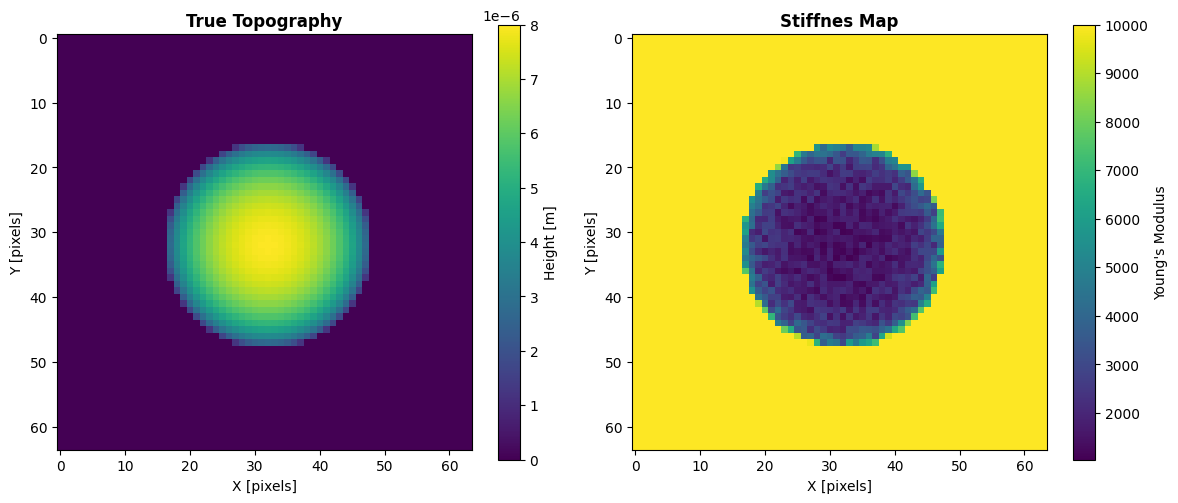

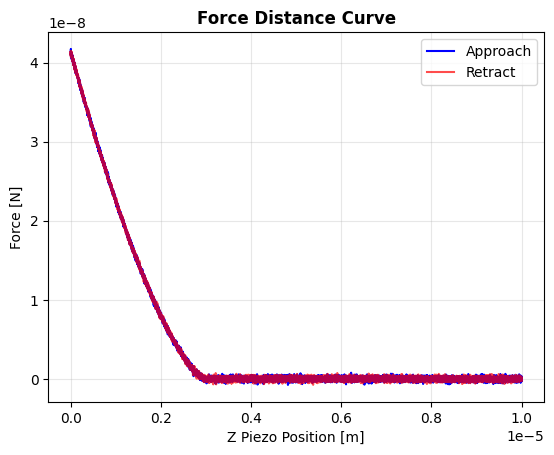

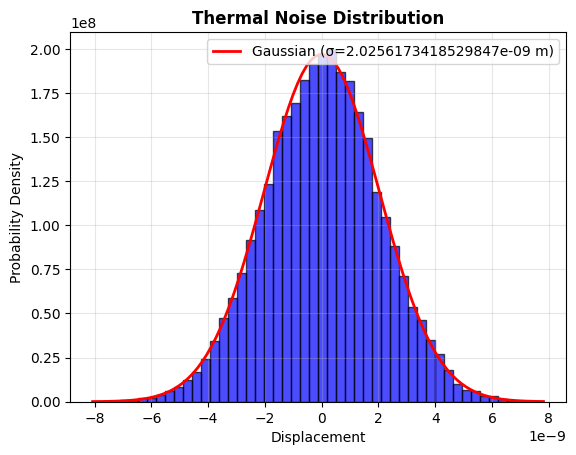

In [69]:
z_piezo, deflection, force, thermal_noise = simulator.simulate_fdc(
    z_length=10e-6,
    setpoint_force=1e-9,
    f=2048,
    height=2e-6,
    E = 2e3,
    approach_rate=2,
    include_thermal_noise=True
)

plot_maps(topography, E_map)
plot_fdc(z_piezo, force, 'Force Distance Curve', 'Z Piezo Position [m]','Force [N]')
plot_noise(thermal_noise, 'Thermal Noise Distribution', 'Displacement', 'Probability Density')

And continue for the rest of our topgraphy

In [14]:
# measured_map = np.zeros((topography.shape[0],topography.shape[1]), dtype=np.float64)
rows, cols = topography.shape[0], topography.shape[1]
grid_z_piezo = [[[0,0,0] for _ in range(cols)] for _ in range(rows)]
grid_force = [[[0,0,0] for _ in range(cols)] for _ in range(rows)]
grid_noise = [[[0,0,0] for _ in range(cols)] for _ in range(rows)]

for i in range(topography.shape[0]):
    for j in range(topography.shape[1]):

        height = topography[i,j]
        E = E_map[i,j]

        z_piezo, deflection, force, thermal_noise = simulator.simulate_fdc(
            z_length=10e-6,
            setpoint_force=1e-9,
            f=2048,
            height=height,
            E = E,
            approach_rate=1,
            include_thermal_noise=True
        )

 
        grid_z_piezo[i][j] = z_piezo
        grid_force[i][j] = force
        grid_noise[i][j] = thermal_noise

grid_force=np.array(grid_force)
print(grid_force.shape)

(64, 64, 40960)


- Visualize:

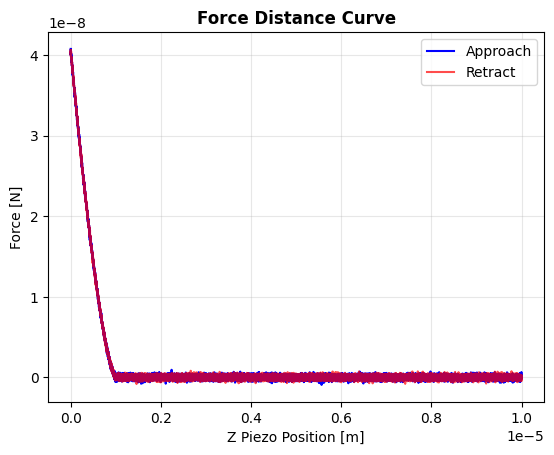

In [70]:
z_piezo = grid_z_piezo[0][0]
force = grid_force[0][0]

plot_fdc(z_piezo, force, 'Force Distance Curve', 'Z Piezo Position [m]','Force [N]')